In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM
from functools import partial


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [3]:

import scipy
def img_aug(x):
    xs_batch = x["image"]
    xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*5, axes=(1,2), reshape=False)

    # Normalize to [0, 1] and add small uniform noise for dequantization
    xs_batch = xs_batch.astype(np.float32) / 255.0
    xs_batch += np.random.uniform(0, 1/255, xs_batch.shape)
    # Move to [-1,1]
    xs_batch = 2*xs_batch - 1
    xs_batch = np.clip(xs_batch, -1.0, 1.0)
    return xs_batch[...,None]

In [4]:
from probjax.nn.io_util import chunkify, unchunkify

In [5]:
data = img_aug(dataset['train'][:])
data = np.arctanh(data * 0.999)  # Inverse tanh transform to unconstrained space
mu0 = np.mean(data, axis=0)
std = np.std(data, axis=0) + 0.001

def normalize(x):
    xs_unconstrained = jnp.arctanh(x*0.999)
    return (xs_unconstrained - mu0) / std
def denormalize(x):
    xs_unconstrained = x * std + mu0
    return jnp.tanh(xs_unconstrained)

def to_seq(x):
    return jax.vmap(partial(chunkify, chunk_shape=(2,2)))(x)

def to_img(x):
    return jax.vmap(partial(unchunkify, chunk_shape=(2,2), spatial_shape=(28,28)))(x)

In [6]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256, num_prefetch_host=8, num_prefetch_device=2, shard=False, host_transforms=[img_aug, normalize], num_async_workers=1)

In [7]:
datastream = iter(loader)

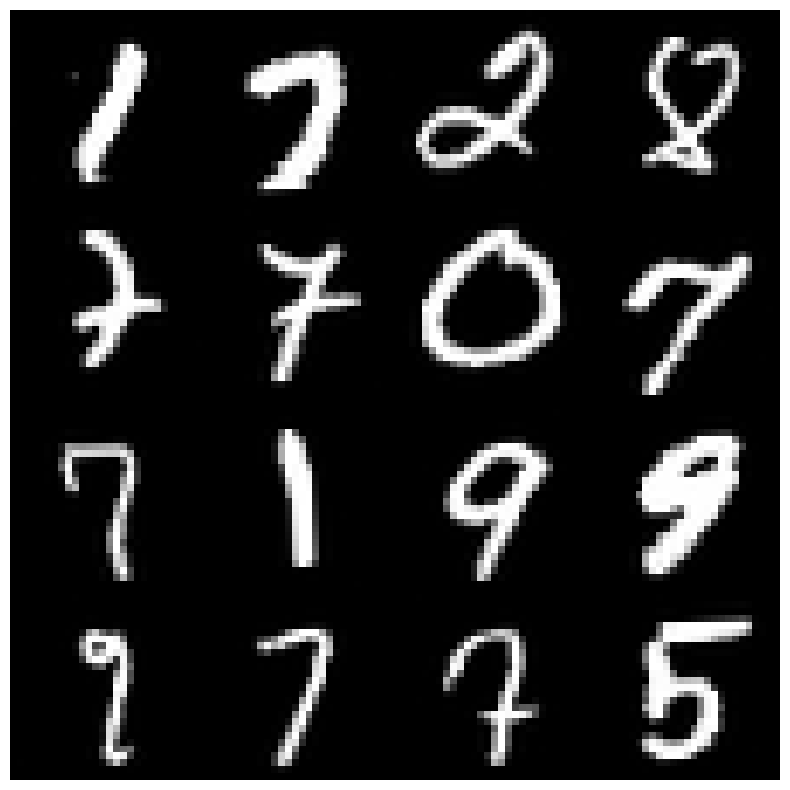

In [8]:
images = denormalize((next(datastream)))[:16,:,:,0]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [9]:
from probjax.nn import Transformer, ResizeConv, SpatialSelfAttention, PosEncode, GatedFuse, RotaryPosEncode
from probjax.nn.layers.attention import MultiHeadAttention, flex_attention
from functools import partial
import time

In [10]:
shapes = [(16,16), (8,8),(4,4)]
mha_cls = partial(MultiHeadAttention, attention_fn=flex_attention)
# Alternatively try ConvTranspose
# conv_up_cls = partial(ConvTranspose, kernel_size=(3,3))
# conv_down_cls = partial(Conv, kernel_size=(3,3))

In [11]:

class Denoiser(nnx.Module):
    def __init__(self, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,128, rngs=rngs, learnable=True)
        self.pos_encode = RotaryPosEncode(256,rngs=rngs)
        self.enc = nnx.Linear(4, 256, rngs=rngs)
        self.dec = nnx.Linear(256, 4, rngs=rngs, kernel_init=nnx.initializers.zeros)
        self.net = Transformer(
            256,
            8,
            8,
            32,
            context_dim=128,
            attention_fn=flex_attention,
            dropout_rate=0.2,
            rngs=rngs,
            dtype=jnp.bfloat16,
            precision="BF16_BF16_F32",
            preferred_element_type=jnp.float32,
            attn_fuse_cls=GatedFuse,
        )

    def __call__(self, t, x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        tokens = to_seq(x)
        tokens = self.enc(tokens)
        tokens = self.pos_encode(tokens)
        tokens = self.net(tokens, context=time_embed)
        out = self.dec(tokens)
        out = to_img(out)
        return out

net = Denoiser(nnx.Rngs(0))
model = EDM(net,loss_type="v")
graphdef, params, state = nnx.split(model, nnx.Param, ...)

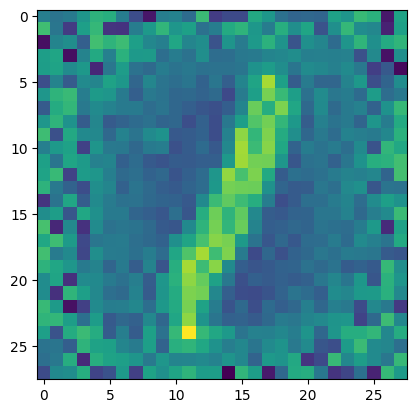

ValueError: No `deterministic` argument was provided to MultiHeadAttention
                    as either a __call__ argument, class attribute, or nnx.flag.

In [12]:
x = next(datastream)
plt.imshow(x[0])
plt.show()
plt.imshow(model(jnp.ones((256,1,1,1))*0.5,x,verbose=True)[0])
plt.colorbar()

In [ ]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  8950596


In [ ]:


def loss_fn(params, state, x, rng):
    model = nnx.merge(graphdef, params, state)
    model.train()

    l = model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-3)
    _, _, state = nnx.split(model, nnx.Param, ...)
    return l, state


In [ ]:
model.loss(jax.random.PRNGKey(0), x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-3)

Array(3.783, dtype=float32)

In [ ]:
from functools import partial
import optax

opt = optax.chain(optax.adaptive_grad_clip(5.), optax.radam(1e-4))
opt_state = opt.init(params)
ema = optax.ema(0.99)
ema_state = ema.init(params)

@jax.jit
def update(params, state, opt_state, ema_state, x, rng):
    (loss, state), grads = jax.value_and_grad(loss_fn, has_aux=True)(params,state, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    _,ema_state = ema.update(params, ema_state)
    return params, state, opt_state, ema_state, loss

def train_step(params,state, opt_state, ema_state, xs, rng):
    params, state, opt_state, ema_state, losses = update(params, state, opt_state, ema_state, xs, rng)
    return params, state, opt_state, ema_state, jnp.mean(losses)


In [ ]:
key = jax.random.key(2)

In [ ]:
from probjax.utils.bmutil import benchmark

In [ ]:
params, state, opt_state, ema_state, loss = benchmark(train_step,params, state,opt_state, ema_state, next(datastream), key)

GPU Utilization: 90% +/- 13%,GPU Memory Utilization: 72% +/- 12% 
CPU Utilization: 0% +/- 0%
Memory Utilization: 0% +/- 0%
Average time taken: 60.07 ms


In [ ]:
# Example training iteration
for i in range(50):
    losses = []
    key, key_loss = jax.random.split(key, 2)
    key_loss = jax.random.split(key_loss, 500)
    for j in range(500):
        xs = next(datastream)
        params, state, opt_state, ema_state, loss = train_step(params, state, opt_state, ema_state, xs, key_loss[j])
        losses.append(loss)
    print(sum(losses) / len(losses))

3.4197757
3.4204926
3.4200456
3.420854
3.420229
3.4195364
3.4187212
3.4190705
3.4190912
3.4191432
3.4186099
3.4181767
3.4177606
3.4182827
3.4187732
3.4179988
3.4176629
3.4170403


KeyboardInterrupt: 

In [46]:
ema_params, ema_state = ema.update(params, ema_state)

In [47]:
model = nnx.merge(graphdef, ema_params, state)
model.eval()

In [48]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (1,28,28,1,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(256)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    out = odeint(drift, eps,ts, method="heun")[-1]
    return denormalize(out)


In [49]:
keys = jax.random.split(jax.random.key(0), (64,))

In [50]:
xs = jax.vmap(sample)(keys)

In [51]:
xs.min(),xs.max()

(Array(-0.999, dtype=float32), Array(0.999, dtype=float32))

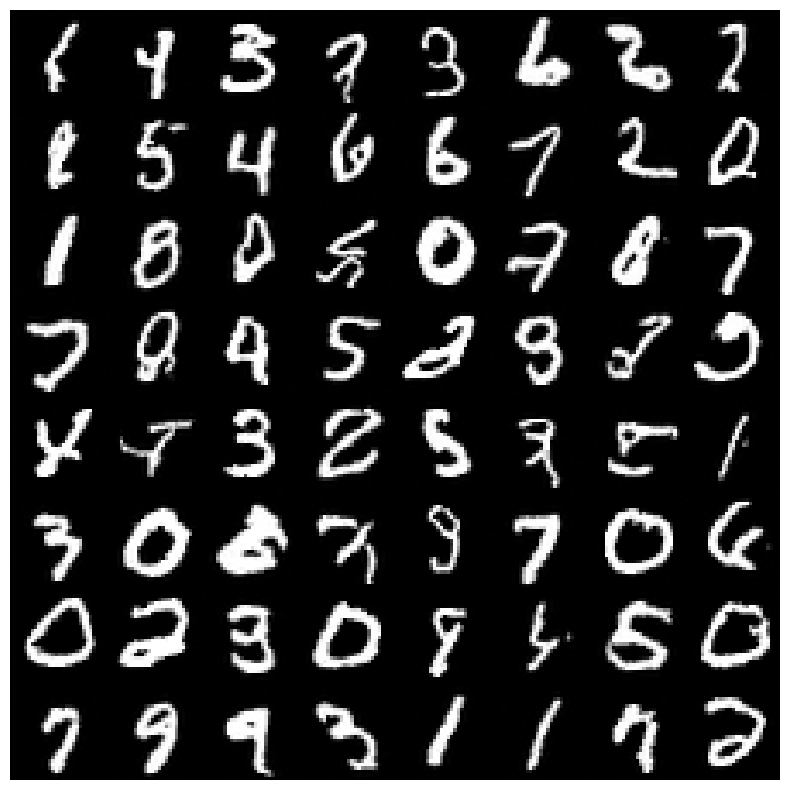

In [52]:
import matplotlib.pyplot as plt


img = xs.reshape(8, 8, 28, 28).transpose(0, 2, 1, 3).reshape(8*28, 8*28)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
plt.axis('off')
plt.show()

: 

: 